# QTL annotations


See if QTL effect sizes correlate better with our REF vs. non-REF VEPs.


NOTES: 
- We may need to match Flashzoi tracks to the specific QTL tissue (unlike the EnsemblVEP annotations which are tissue-agnostic).
- We may not see much overlap beteen our clinical variants (rare and deleterious) and QTLs variants (common and relatively benign).
- While the VEPs of the clinical variants themselves might not show a correlation, WT variants that modify VEP might.


In [5]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils  
import src.ensemblVEP as ev
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import VEP results

### SpliceAI

In [55]:
spliceai_df_path = "../data/1000_Genomes_on_GRCh38/SpliceAI/spliceai_clinvar_merged.parquet"
vep_df = pd.read_parquet(spliceai_df_path)
vep_df["is_ref"] = vep_df["sample"] == "REF"
vep_df.head()

,variant_idx,chromosome,position,ref_allele,alt_allele,sample_id,hap_id,flag,max_delta_score,max_delta_coord,max_delta_score_type,max_delta_strand,pos_acceptor_gain_max,pos_acceptor_gain_max_coord,pos_acceptor_loss_max,pos_acceptor_loss_max_coord,pos_donor_gain_max,pos_donor_gain_max_coord,pos_donor_loss_max,pos_donor_loss_max_coord,neg_acceptor_gain_max,neg_acceptor_gain_max_coord,neg_acceptor_loss_max,neg_acceptor_loss_max_coord,neg_donor_gain_max,neg_donor_gain_max_coord,neg_donor_loss_max,neg_donor_loss_max_coord,sample,Population,Super Population,chr,pos,clinvar_id,ref,alt,3ss_can,3ss_eprox,3ss_iprox,bp_region,5ss_can,5ss_eprox,5ss_iprox,exon_core,svdb_id,hgvs,method,spliceogenicity,gene,GENEINFO,CLNSIG,CLNREVSTAT,CLNSIG_simplified,site,VEP,is_ref
0,0,chr10,236835,T,C,0,0,0,0.065125,236840,acceptor_loss,pos,0.004395,236838,0.065125,236840,0.000002,236841,0.000078,236840,0.000016,236883,4.172325e-07,236833,0.013672,236883,1.788139e-07,236873,HG00096,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065125,False
1,0,chr10,236835,T,C,0,1,0,0.067566,236840,acceptor_loss,pos,0.003906,236838,0.067566,236840,0.000001,236841,0.000080,236840,0.000016,236883,4.172325e-07,236833,0.013794,236883,1.192093e-07,236873,HG00096,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.067566,False
2,0,chr10,236835,T,C,1,0,0,0.065735,236840,acceptor_loss,pos,0.004395,236838,0.065735,236840,0.000001,236841,0.000077,236840,0.000017,236883,4.172325e-07,236833,0.013184,236883,1.192093e-07,236873,HG00097,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065735,False
3,0,chr10,236835,T,C,1,1,0,0.065491,236840,acceptor_loss,pos,0.004395,236838,0.065491,236840,0.000001,236841,0.000079,236840,0.000017,236883,4.172325e-07,236833,0.013916,236883,1.788139e-07,236873,HG00097,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065491,False
4,0,chr10,236835,T,C,2,0,0,0.065430,236840,acceptor_loss,pos,0.004395,236838,0.065430,236840,0.000001,236841,0.000078,236840,0.000016,236883,4.172325e-07,236833,0.013306,236883,1.192093e-07,236873,HG00099,GBR,EUR,chr10,236835,2807434,T,C,0,0,1,0,0,0,0,0,5219,NM_001370100.5:c.439-3T>C,MFASS,Low-frequency,ZMYND11,ZMYND11:10771,Uncertain_significance,1,vus,chr10:236835-236836_T_C,0.065430,False


### All others (Flashzoi)

In [2]:
variant_set="clinvar_utr_snv"
xr_mfds_dir=os.path.join(
    os.path.expanduser('~'),
    "projects/data/1000_Genomes_on_GRCh38",
    variant_set
)

pq_file = os.path.join(xr_mfds_dir, "vep_df.parquet")  
vep_df = pd.read_parquet(pq_file)
vep_df["is_ref"] = vep_df["sample"] == "REF"

# Set cached annotation file path
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ClinVar_UTR.csv.gz")

## Import QTL data


QTL data source: https://www.finucanelab.org/data (GTEx fine-mapping results)

In [200]:

# gtex = pl.read_csv(
#     os.path.expanduser("~/projects/data/QTL/Public_GTEx_finemapping/GTEx_49tissues_release1.tsv.bgz"),
#     separator="\t", 
# )


QTL data source: https://www.finucanelab.org/data (Expression Modifier Score (EMS) in 49 tissues )

In [ ]:
import gzip
import re

files = glob.glob(os.path.expanduser("~/projects/data/QTL/EMS_public/*.tsv.bgz"))

r2_df = []
for file in tqdm(files, desc="Processing tissues"):
    tissue = re.search(r'ems_top_(.+?)\.tsv\.bgz$', os.path.basename(file)).group(1)
    ems = pd.read_csv(gzip.open(file, "rt"), sep="\t")
    
    # Add variant name
    ems['chrom'] = ems['v'].str.split('_').str[0]
    ems['chromStart'] = ems['v'].str.split('_').str[1].astype(int) 
    ems['REF'] = ems['v'].str.split('_').str[2]
    ems['ALT'] = ems['v'].str.split('_').str[3]
    ems = utils.add_variant_name(ems,
                                chrom_col='chrom',
                                start_col='chromStart',
                                end_col=None,
                                ref_col='REF',
                                alt_col='ALT',
                                alias='site',
                                force=False)

    # Aggregate VEP scores
    agg_cols = [x for x in ["is_ref","site","spliceogenicity","CLNSIG_simplified"] if x in vep_df.columns]
    vep_agg = vep_df.groupby(agg_cols, observed=True)["VEP"].mean().reset_index()

    # Merge VEP and EMS
    vep_agg["site"] = vep_agg["site"].astype(object)
    ems["site"] = ems["site"].astype(object)
    vep_annot = vep_agg.merge(ems, on="site", how="inner")

    # Check if there are any variants
    if vep_annot.empty:
        print(f"No overlapping variants found for {tissue}")
        continue
    
    # Run correlation analysis
    r2_tmp = ev.run_correlation_analysis(vep_annot, 
                                         ANNOT_COLS=["rf_score_raw","ems","ems_normalized"],
                                        #  transform="exp2",
                                         verbose=False)
    r2_tmp["tissue"] = tissue 
    r2_df.append(r2_tmp)

r2_df = pd.concat(r2_df)
r2_df.head() 

Processing tissues:   0%|          | 0/49 [00:00<?, ?it/s]/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp2
  result = getattr(ufunc, method)(*inputs, **kwargs)
Processing tissues:   2%|▏         | 1/49 [00:04<03:33,  4.44s/it]/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp2
  result = getattr(ufunc, method)(*inputs, **kwargs)
Processing tissues:   6%|▌         | 3/49 [00:10<02:28,  3.22s/it]/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp2
  result = getattr(ufunc, method)(*inputs, **kwargs)
Processing tissues:   8%|▊         | 4/49 [00:12<02:10,  2.90s/it]/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp2
  result = getattr(ufunc,

,annotation,ref_r,nonref_r,r_diff,rabs_diff,r2_diff,ref_n,nonref_n,ref_p,nonref_p,ref_fdr,nonref_fdr,combined_diff,combined_abs_diff,combined2_diff,tissue
0,rf_score_raw,0.138234,0.147043,0.008808,0.008808,0.002513,309,309,0.015025,0.009643,0.015025,0.009643,0.009468,0.009468,0.002668,Lung
1,ems,0.160686,0.168205,0.007519,0.007519,0.002473,309,309,0.004632,0.003017,0.006948,0.004526,0.007756,0.007756,0.002541,Lung
2,ems_normalized,0.164368,0.171361,0.006993,0.006993,0.002348,309,309,0.003763,0.002508,0.006948,0.004526,0.007182,0.007182,0.002404,Lung
0,rf_score_raw,0.179189,0.025381,-0.153808,-0.153808,-0.031465,173,173,0.018329,0.740295,0.054987,0.740295,-0.169313,-0.169313,-0.030899,Ovary
1,ems,0.050825,0.029931,-0.020893,-0.020893,-0.001687,173,173,0.506642,0.695856,0.506642,0.740295,-0.015971,-0.015971,-0.000546,Ovary


<string>:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


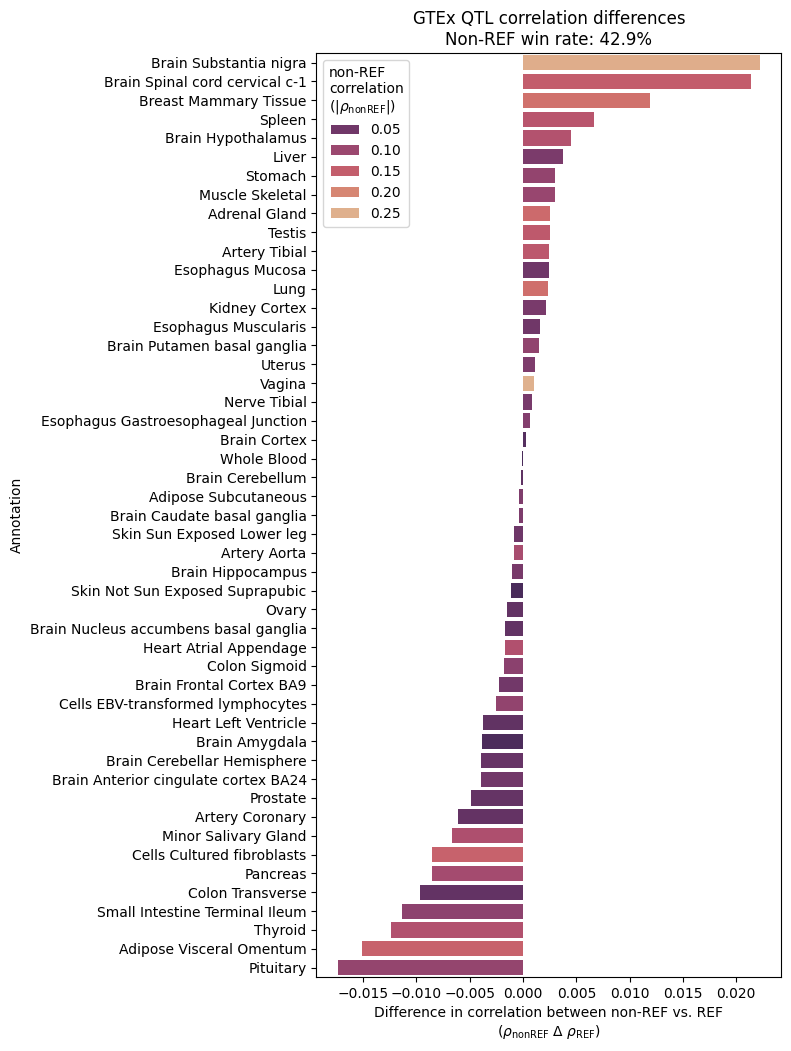

In [196]:
r2_df["tissue_annotation"] = r2_df["tissue"] + " (" + r2_df["annotation"] + ")" 

min_n = 0
max_p = 0.05
r2_filt = ev.plot_correlation_analysis(r2_df, 
                            x_var="r2_diff",
                            #  min_n=20,
                            #  max_p=0.05,
                             annotations=["ems_normalized"],
                             figsize=(6, 12),
                             hue="nonref_r_abs", 
                             y_var="tissue",
                             title="GTEx QTL correlation differences")

In [169]:
(r2_filt["r_diff"]>0).sum() / len(r2_filt)

0.5384615384615384

In [170]:
r2_filt.groupby(["annotation"])["r_diff"].mean()

annotation
ems_normalized   -0.001172
Name: r_diff, dtype: float64

## Tissue-specific Flashzoi correlations

First, we need to find clinical variants with a high degree of inter-population variation in their VEP scores.

In [11]:
og_meta = og.get_sample_metadata()
og_meta

,sample,sex,Biosample ID,Population code,population_name,superpopulation,superpopulation_name,population,Data collections
0,HG00157,male,SAME124590,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
1,HG00171,female,SAME124961,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00176,female,SAME124956,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,HG00183,male,SAME123642,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
4,HG00188,male,SAME123641,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
...,...,...,...,...,...,...,...,...,...
4984,GM19129,female,NaN,YRI,Yoruba,AFR,African Ancestry,YRI,"Human Genome Structural Variation Consortium, ..."
4985,NA15204,female,NaN,NaN,Hungarian,NaN,West Eurasia (SGDP),HungarianSGDP,1KG_ONT_VIENNA
4986,NA15730,female,NaN,NaN,Czech,NaN,West Eurasia (SGDP),CzechSGDP,1KG_ONT_VIENNA
4987,NA18741,female,NaN,CHB,Han Chinese,EAS,East Asian Ancestry,CHB,1KG_ONT_VIENNA


In [12]:
vep_pops = vep_df[["sample","site","VEP"]].merge(
    og_meta[["sample","superpopulation"]].drop_duplicates(), 
    on="sample", how="inner")

In [14]:
vep_pops

,sample,site,VEP,superpopulation
0,HG00096,chr19:6502208-6502209_C_T,2.046385,EUR
1,HG00096,chr19:6502208-6502209_C_T,1.986162,EUR
2,HG00097,chr19:6502208-6502209_C_T,2.527947,EUR
3,HG00097,chr19:6502208-6502209_C_T,1.785020,EUR
4,HG00099,chr19:6502208-6502209_C_T,1.936056,EUR
...,...,...,...,...
10671019,NA21142,chrX:9725612-9725613_G_A,1.309572,SAS
10671020,NA21143,chrX:9725612-9725613_G_A,1.309572,SAS
10671021,NA21143,chrX:9725612-9725613_G_A,1.309572,SAS
10671022,NA21144,chrX:9725612-9725613_G_A,1.309633,SAS


In [29]:
# Compute the between-superpopulation variance per site
top_variants = (
    vep_pops.groupby(["site", "superpopulation"])["VEP"].mean()
    .reset_index()
    .groupby("site")["VEP"].var()
    .sort_values(ascending=False)
    .reset_index()
) 
top_variants["chrom"] = top_variants["site"].str.split(":").str[0]
top_variants.head()

,site,VEP,chrom
0,chr19:6368863-6368864_C_G,2.558602,chr19
1,chr1:25817330-25817331_T_C,2.478026,chr1
2,chr22:18089710-18089711_G_C,0.798528,chr22
3,chr19:11132656-11132657_C_A,0.643002,chr19
4,chr19:11132670-11132671_T_C,0.316646,chr19


Visualize the variance between populations for these selected variants.

In [ ]:
vep_df.loc[vep_df["site"].isin(top_variants["site"])]

### Run inference with Flashzoi

In [39]:
top_variants["site"]

0          chr19:6368863-6368864_C_G
1         chr1:25817330-25817331_T_C
2        chr22:18089710-18089711_G_C
3        chr19:11132656-11132657_C_A
4        chr19:11132670-11132671_T_C
                    ...             
2089      chrX:67686064-67686065_G_A
2090      chrX:54446267-54446268_G_A
2091      chrX:48479062-48479063_C_G
2092    chrX:154031436-154031437_G_T
2093      chrX:92618779-92618780_G_C
Name: site, Length: 2094, dtype: string

In [43]:
site_names

[]

In [ ]:
# Steamlined version

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")
warnings.filterwarnings("ignore", category=UserWarning, message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")

import torch
import src.vep_pipeline as vp
import src.clinvar as cv
import src.onekg as og
from IPython.display import clear_output 

force=True
middle_n = None#2000//32
# Import bed file
bed = cv.read_bed("data/UTR/clinvar_utr_snv.bed.gz")

n_top_variants = 1
site_names = top_variants["site"].unique().tolist()[:n_top_variants]


## Check if saved site results already exist
save_dir = f"{os.getcwd()}/tmp/UTR/trks_covr"
os.makedirs(save_dir, exist_ok=True)
site_paths = {sn: os.path.join(save_dir, sn) for sn in site_names}
if not force:
    site_names = [sn for sn, site_path in site_paths.items() if not os.path.exists(site_path) or force]
if site_names == []:
    raise ValueError("No sites selected.")
# Split samples into batches
max_seqs_per_batch = 100
sample_meta = og.get_sample_metadata()
batched_samples = utils.split_batches(samples=sample_meta["sample"].tolist(), 
                                      max_seqs_per_batch=max_seqs_per_batch)  

# Limit to 2 batches for testing
batched_samples = batched_samples[:1]

# Iterate over batches
trks_covr = {}
for batch_idx, batch_samples in tqdm(enumerate(batched_samples),
                                      total=len(batched_samples),
                                      desc="Iterating over batches"):
  print(f"Processing batch {batch_idx} of {len(batched_samples)}")
  
  # # Run VEP pipeline for 1KG dataset (all chromosomes)
  raw_results = vp.vep_pipeline_onekg(bed=bed, 
                              #   limit_chroms=bed_filt["chrom"].unique().to_list()[:1],
                                limit_chroms=top_variants.loc[top_variants["site"].isin(site_names), "chrom"].unique().tolist(),
                                limit_samples=batch_samples,
                                # limit_sites=3,
                                # force_gvl=True,
                                # force_vep=2,
                              
                                variant_set="clinvar_utr_snv",
                                site_filters={"name": site_names},
                                run_models=["flashzoi"], 
                                device="cuda:1", 
                                verbose=1,
                                return_raw=True)
  
  if len(raw_results['chr19']['results']) ==0:
     raise ValueError(f"No results found for batch {batch_idx}")
  
  # Extract tracks
  trks_samples = vp.raw_results_to_site_results(raw_results = raw_results, 
                                          middle_n=None,
                                          use_torch=False,
                                          key="samples")
  trks_wt = vp.raw_results_to_site_results(raw_results = raw_results, 
                                          middle_n=None,
                                          key="trks_wt")
  trks_mut = vp.raw_results_to_site_results(raw_results = raw_results, 
                                            middle_n=middle_n,
                                            key="trks_mut") 
  # Compute disaggregated COVR scores
  for site_name in tqdm(trks_wt.keys(), 
                        desc="Calculating disaggregated COVR"): 
      
      # Return per-person, per-track COVR scores
      covr = ( (trks_mut[site_name] + 1e-6) / (trks_wt[site_name] + 1e-6) ).log2().abs()
      if site_name not in trks_covr:
        trks_covr[site_name] = covr
      else:
        trks_covr[site_name] = torch.cat([trks_covr[site_name], covr], dim=0)

  # del raw_results, trks_wt, trks_mut
  torch.cuda.empty_cache()
  
 # Clear output to avoid overloading the notebook
  clear_output(wait=True)

  # End for loop 

# Save results
for site_name, site_path in tqdm(site_paths.items(), desc="Saving trks_covr"):
    torch.save(trks_covr[site_name].cpu(), site_path)
  

Extracting ID columns.
Using default maps.
Simplifying annotations.


Iterating over batches:   0%|          | 0/1 [00:00<?, ?it/s]

Processing batch 0 of 1


Iterating over chromosomes:   0%|          | 0/1 [00:00<?, ?it/s]



2025-08-08 13:53:44.159 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-08-08 13:53:44.199 | INFO     | genvarloader._dataset._reconstruct:from_path:183 - Loading variant data.
2025-08-08 13:53:44.251 | INFO     | genvarloader._dataset._impl:open:278 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr19.gvl
Is subset: False
# of regions: 556
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None

2025-08-08 13:53:44.318 | INFO     | genvarloader._dataset._impl:open:192 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-08-08 13:53:44.344 | INFO     | genvarloader._dataset._reconstruct:from_path

Dataset will be saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr19.zarr
Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr19.zarr
xarray Dataset dimensions: FrozenMappingWarningOnValuesAccess({'site': 556, 'sample': 2549, 'ploid': 2, 'slot': 14})
Using reference genome from /home/schilder/.cache/pooch/296ca04ba1df562072adc4c76f64cfb9-GRCh38_full_analysis_set_plus_decoy_hla.fa


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sample batches (43 samples total):   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
for site_name in trks_covr.keys(): 
    samples = trks_samples[site_name]
    for pop in og_meta["superpopulation"].dropna().unique():
        pop_samples = og_meta[og_meta["superpopulation"] == pop]["sample"].unique()
        # trks_covr[site_name][pop]

In [59]:
pop_samples

array(['HG02603', 'HG02494', 'HG02691', 'HG02696', 'HG02728', 'HG02735',
       'HG02778', 'HG02780', 'HG02653', 'HG02658', 'HG02660', 'HG02684',
       'HG02689', 'HG02785', 'HG02792', 'HG03012', 'HG03017', 'HG03238',
       'HG03593', 'HG03598', 'HG03492', 'HG03606', 'HG03618', 'HG03620',
       'HG03625', 'HG03714', 'HG03719', 'HG03721', 'HG03733', 'HG03738',
       'HG03740', 'HG03644', 'HG03649', 'HG03651', 'HG03656', 'HG03663',
       'HG03668', 'HG03682', 'HG03687', 'HG03694', 'HG03699', 'HG03702',
       'HG03707', 'HG03745', 'HG03752', 'HG03757', 'HG03769', 'HG03771',
       'HG03808', 'HG03815', 'HG03822', 'HG03834', 'HG03783', 'HG03788',
       'HG03790', 'HG03795', 'HG03846', 'HG03858', 'HG03872', 'HG03884',
       'HG03896', 'HG03803', 'HG04197', 'HG04200', 'HG04212', 'HG04217',
       'HG04229', 'HG03942', 'HG03947', 'HG03973', 'HG03978', 'HG03985',
       'HG04159', 'HG04161', 'HG04173', 'HG04180', 'HG04185', 'HG04192',
       'HG03904', 'HG03909', 'HG03911', 'HG03916', 

In [56]:
og_meta["superpopulation"].dropna().unique()

array(['EUR', 'EAS', 'AMR', 'AFR', 'SAS'], dtype=object)

In [53]:
samples

{'chr19:6368863-6368864_C_G': array(['HG00099', 'HG00102', 'HG00107', 'HG00114', 'HG00119', 'HG00121',
        'HG00126', 'HG00133', 'HG00138', 'HG00140', 'HG00145', 'HG00152',
        'HG00157', 'HG00171', 'HG00176', 'HG00183', 'HG00188', 'HG00190',
        'HG00234', 'HG00239', 'HG00246', 'HG00253', 'HG00258', 'HG00260',
        'HG00265', 'HG00272', 'HG00277', 'HG00284', 'HG00304', 'HG00309',
        'HG00443', 'HG00448', 'HG00479', 'HG00513', 'HG00525', 'HG00537',
        'HG00551', 'HG00556', 'HG00638', 'HG00640', 'HG00657', 'HG00671',
        'HG00683'], dtype='<U7')}

In [19]:
trks_covr[site_name].shape

torch.Size([86, 7611, 6144])